In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

from matplotlib.pyplot import figure
from astropy.io import fits
from astropy.table import Table

from astropy import units as u
from astropy.table import QTable

import random

import jax
import jax.numpy as jnp

In [30]:
lambdas = np.linspace(846, 870, 2401)

df_stars = pd.read_pickle('../data/stars.pkl')

giants = df_stars[(df_stars['logg']>1.5) & (df_stars['logg']<3.5)]
dwarfs = df_stars[df_stars['logg'] > 4]

In [31]:
Fe_Is = [848.296, 851.641, 852.901, 857.416, 858.462, 862.397, 867.713, 869.101]
Fe_IIs = [858.794]
offset = 0.3

ca_centers = [850, 854.4, 866.5]

(0.0, 1.1)

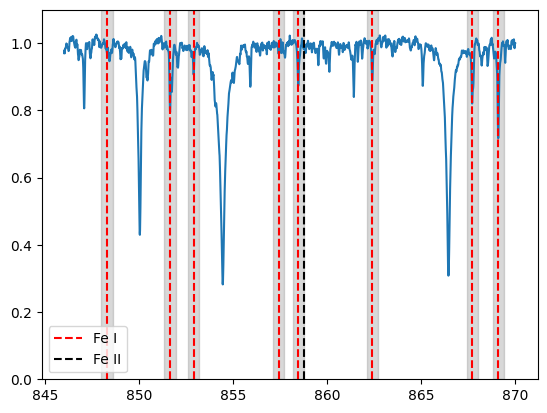

In [32]:
star_example = giants.iloc[0]
plt.plot(lambdas, star_example['flux'])

for i in range(len(Fe_Is)):
    plt.axvspan(Fe_Is[i] - offset, Fe_Is[i] + offset, alpha = 0.3, color = 'gray')
plt.vlines(Fe_Is, 0, 1.1, color = 'red', linestyle = '--', label = 'Fe I')
plt.vlines(Fe_IIs, 0, 1.1, color = 'black', linestyle = '--', label = 'Fe II')

#plt.axvspan(ca_centers[2] - offset, ca_centers[2] + offset, alpha=0.3, color='gray')
plt.legend()
plt.ylim(0,1.1)


In [33]:
mask = np.zeros_like(lambdas, dtype=int)

for center in Fe_Is:
    mask[(lambdas >= center - offset) & (lambdas <= center + offset)] = 1

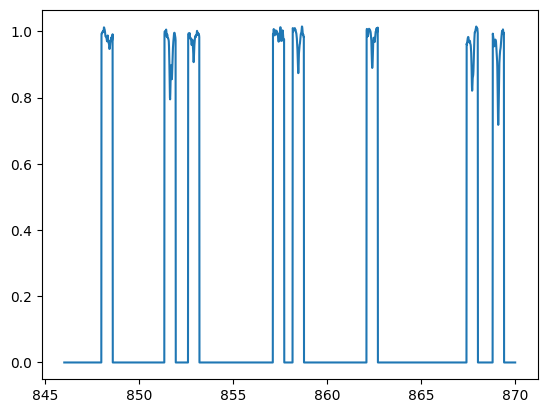

In [34]:
plt.plot(lambdas, mask * star_example['flux'])

In [36]:
n_flux = len(lambdas)
n_latents = 21

ELEMENT_MASK = jnp.zeros((n_flux, n_latents))

for center in Fe_Is:
    idx = (lambdas >= center - offset) & (lambdas <= center + offset)
    ELEMENT_MASK = ELEMENT_MASK.at[idx, :].set(1)

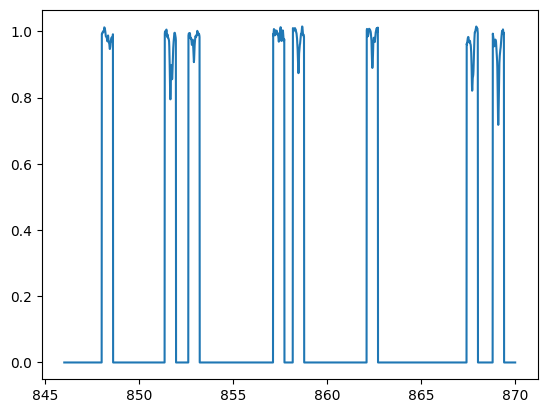

In [38]:
mask_1d = ELEMENT_MASK[:, 0]
flux = star_example['flux'].filled(0)
plt.plot(lambdas, np.array(mask_1d) * flux)